<a href="https://colab.research.google.com/github/ashishmanojjohn-tech/chatgpt-review-anaylsis/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

## Google Colab is available in VS Code!
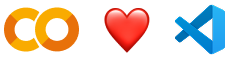

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## 🎁 Free Pro Plan for Gemini & Colab for US College Students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research, and innovative projects, backed by Colab’s dedicated high-compute resources for data science and machine learning.

Get the Gemini free offer at [gemini.google/students](https://gemini.google/students?utm_source=colab&utm_medium=banner&utm_campaign=students_xpa_us-colab-banner).  
Get the Colab free offer at [colab.research.google.com/signup](https://colab.research.google.com/signup).  
Terms Apply.

In [12]:
import pandas as pd

file_path = '/content/IT Expenditure dataset.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,Date,Business Area,Region,Country,IT Sub Area,IT Area,Cost element name,Cost Element Group,Cost Element Sub Group,Actual,Forecast,Plan
0,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Inbound,Shared Services,Inbound Allocations,NaN,NaN,-5805.03
1,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,61.56,NaN,NaN
2,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,NaN,61.56,NaN
3,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,NaN,NaN,270.01
4,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Regular Salaries And Wages,Labor,Internal Labor,NaN,NaN,-10692.07


In [27]:
import pandas as pd

# Filter for months where Actual spend was zero (September to December)
zero_spend_month_periods = pd.PeriodIndex(['1900-09', '1900-10', '1900-11', '1900-12'], freq='M')
df_zero_spend = df[df['Date'].dt.to_period('M').isin(zero_spend_month_periods)]

display(df_zero_spend.head())

,Date,Business Area,Region,Country,IT Sub Area,IT Area,Cost element name,Cost Element Group,Cost Element Sub Group,Actual,Forecast,Plan,Variance_Actual_Plan,Variance_Actual_Forecast
62887,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Other Inbound,Shared Services,Inbound Allocations,0.0,0.0,-5805.05,5805.05,0.0
62888,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,0.0,0.0,270.01,-270.01,0.0
62889,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Regular Salaries And Wages,Labor,Internal Labor,0.0,0.0,-27054.17,27054.17,0.0
62890,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Travel Expense,Other,Travel,0.0,0.0,-2025.01,2025.01,0.0
62891,1900-09-01,Distribution,Europe,United Kingdom,GRC,Governance,Contractors,Labor,External Labor,0.0,16125.1,0.00,0.00,-16125.1


In [28]:
# Group by Business Area for zero spend months
zero_spend_business_area = df_zero_spend.groupby('Business Area').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_business_area)

,Business Area,Actual,Plan,Forecast
0,BU,0.0,45918064.28,5.153165e+07
1,Distribution,0.0,18258989.75,1.897589e+07
2,Infrastructure,0.0,80056303.85,8.100166e+07
3,Manufacturing,0.0,44069894.19,4.576673e+07
4,Office & Administrative,0.0,57093034.14,5.938399e+07
5,R&D,0.0,30491363.58,4.541202e+07
6,Services,0.0,13208760.42,1.365078e+07


In [29]:
# Group by Country for zero spend months
zero_spend_country = df_zero_spend.groupby('Country').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_country)

,Country,Actual,Plan,Forecast
0,Austria,0.0,5.677811e+05,6.062117e+05
1,Belgium,0.0,2.300608e+06,2.849698e+06
2,Brazil,0.0,2.556612e+06,3.213992e+06
3,Canada,0.0,1.287196e+06,1.556714e+06
4,China,0.0,0.000000e+00,1.469317e+06
5,France,0.0,6.288912e+06,7.747863e+06
6,Germany,0.0,3.027894e+06,2.780491e+06
7,Ireland,0.0,2.377362e+06,1.571383e+06
8,Italy,0.0,2.842324e+06,3.719328e+06
9,Japan,0.0,0.000000e+00,8.337460e+05


In [30]:
# Group by Cost element name for zero spend months
zero_spend_cost_element = df_zero_spend.groupby('Cost element name').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_cost_element)

,Cost element name,Actual,Plan,Forecast
0,Adjustments,0.0,4154.20,10694.0772
1,Admin,0.0,41320.03,0.0000
2,Administrative,0.0,40425.85,46335.8004
3,Administrative Support,0.0,35465.83,0.0000
4,Allowances,0.0,21445.31,26385.0369
...,...,...,...,...
137,Vehicle Fuel,0.0,741.80,-381.4456
138,Vehicle National Tax,0.0,0.00,-28.6668
139,Vendor,0.0,2592.00,10057.1428
140,Waste Disposal,0.0,22000.00,22000.0000


In [31]:
# Group by IT Area for zero spend months
zero_spend_it_area = df_zero_spend.groupby('IT Area').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_it_area)

,IT Area,Actual,Plan,Forecast
0,BU Support,0.0,78891540.89,9.647146e+07
1,Enablement,0.0,16131698.38,1.579482e+07
2,Functional,0.0,98680815.30,1.056229e+08
3,Governance,0.0,18258989.75,1.897589e+07
4,Infrastructure,0.0,77133365.89,7.885762e+07


In [26]:
import pandas as pd

# Filter for months where Actual spend was zero (September to December)
zero_spend_month_periods = pd.PeriodIndex(['1900-09', '1900-10', '1900-11', '1900-12'], freq='M')
df_zero_spend = df[df['Date'].dt.to_period('M').isin(zero_spend_month_periods)]

display(df_zero_spend.head())

,Date,Business Area,Region,Country,IT Sub Area,IT Area,Cost element name,Cost Element Group,Cost Element Sub Group,Actual,Forecast,Plan,Variance_Actual_Plan,Variance_Actual_Forecast
62887,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Other Inbound,Shared Services,Inbound Allocations,0.0,0.0,-5805.05,5805.05,0.0
62888,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,0.0,0.0,270.01,-270.01,0.0
62889,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Regular Salaries And Wages,Labor,Internal Labor,0.0,0.0,-27054.17,27054.17,0.0
62890,1900-09-01,R&D,Europe,United Kingdom,Planning,BU Support,Travel Expense,Other,Travel,0.0,0.0,-2025.01,2025.01,0.0
62891,1900-09-01,Distribution,Europe,United Kingdom,GRC,Governance,Contractors,Labor,External Labor,0.0,16125.1,0.00,0.00,-16125.1


In [22]:
# Group by Business Area for zero spend months
zero_spend_business_area = df_zero_spend.groupby('Business Area').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_business_area)

,Business Area,Actual,Plan,Forecast


In [23]:
# Group by Country for zero spend months
zero_spend_country = df_zero_spend.groupby('Country').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_country)

,Country,Actual,Plan,Forecast


In [24]:
# Group by Cost element name for zero spend months
zero_spend_cost_element = df_zero_spend.groupby('Cost element name').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_cost_element)

,Cost element name,Actual,Plan,Forecast


In [25]:
# Group by IT Area for zero spend months
zero_spend_it_area = df_zero_spend.groupby('IT Area').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum'
}).reset_index()

display(zero_spend_it_area)

,IT Area,Actual,Plan,Forecast


In [18]:
# Group by Country and calculate sums and variances
country_expenditure = df.groupby('Country').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum',
    'Variance_Actual_Plan': 'sum',
    'Variance_Actual_Forecast': 'sum'
}).reset_index()

display(country_expenditure)

,Country,Actual,Plan,Forecast,Variance_Actual_Plan,Variance_Actual_Forecast
0,Austria,1.041984e+06,1.701913e+06,1.703818e+06,-6.599287e+05,-6.618342e+05
1,Belgium,4.683930e+06,6.897532e+06,7.547229e+06,-2.213602e+06,-2.863299e+06
2,Brazil,3.959674e+06,7.729339e+06,7.729339e+06,-3.769665e+06,-3.769665e+06
3,Canada,2.163297e+06,3.867242e+06,3.869874e+06,-1.703944e+06,-1.706577e+06
4,China,0.000000e+00,0.000000e+00,1.953754e+06,0.000000e+00,-1.953754e+06
5,Czech Republic,1.314714e+05,0.000000e+00,0.000000e+00,1.314714e+05,1.314714e+05
6,France,1.313970e+07,2.054176e+07,2.101334e+07,-7.402057e+06,-7.873640e+06
7,Germany,7.946735e+06,9.180430e+06,1.012397e+07,-1.233695e+06,-2.177239e+06
8,Hungary,1.075534e+05,0.000000e+00,0.000000e+00,1.075534e+05,1.075534e+05
9,Ireland,3.474071e+06,7.171659e+06,4.973172e+06,-3.697589e+06,-1.499101e+06


In [19]:
# Group by Cost element name and calculate sums and variances
cost_element_expenditure = df.groupby('Cost element name').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum',
    'Variance_Actual_Plan': 'sum',
    'Variance_Actual_Forecast': 'sum'
}).reset_index()

display(cost_element_expenditure)

,Cost element name,Actual,Plan,Forecast,Variance_Actual_Plan,Variance_Actual_Forecast
0,3rd Party Marketing Data,6400.00,0.00,6400.0000,6400.00,0.0000
1,Adjustments,-726836.71,12462.60,-723093.8542,-739299.31,-3742.8558
2,Admin,0.00,123960.00,0.0000,-123960.00,0.0000
3,Administrative,82107.62,122812.77,130919.0106,-40705.15,-48811.3906
4,Administrative Fees,74971.12,0.00,61641.7800,74971.12,13329.3400
...,...,...,...,...,...,...
200,Vehicle Rent,8903.01,0.00,6067.1600,8903.01,2835.8500
201,Vehicle Rent - Employees,-526.66,0.00,-392.3600,-526.66,-134.3000
202,Vendor,18329.83,7776.00,33415.5442,10553.83,-15085.7142
203,Waste Disposal,31322.00,66000.00,57062.0000,-34678.00,-25740.0000


In [20]:
# Group by IT Area and calculate sums and variances
it_area_expenditure = df.groupby('IT Area').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum',
    'Variance_Actual_Plan': 'sum',
    'Variance_Actual_Forecast': 'sum'
}).reset_index()

display(it_area_expenditure)

,IT Area,Actual,Plan,Forecast,Variance_Actual_Plan,Variance_Actual_Forecast
0,BU Support,1.641863e+08,2.604630e+08,2.654631e+08,-9.627663e+07,-1.012768e+08
1,Enablement,2.534106e+07,4.753845e+07,4.294992e+07,-2.219739e+07,-1.760886e+07
2,Functional,1.784250e+08,2.988134e+08,2.928493e+08,-1.203884e+08,-1.144243e+08
3,Governance,3.288232e+07,5.177806e+07,5.229343e+07,-1.889574e+07,-1.941111e+07
4,Infrastructure,1.548965e+08,2.418095e+08,2.369866e+08,-8.691301e+07,-8.209012e+07


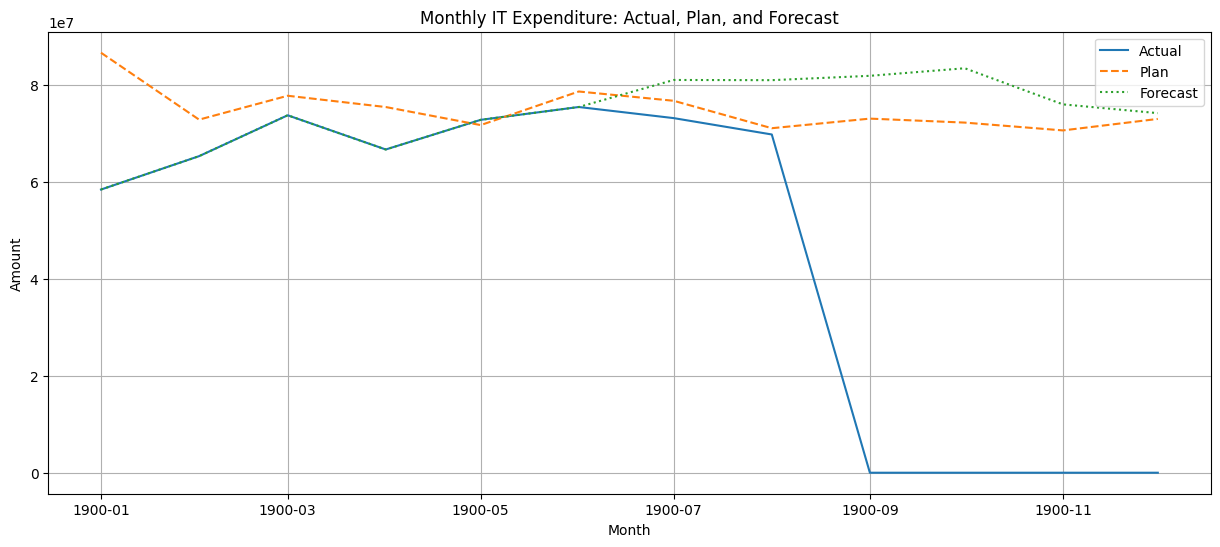

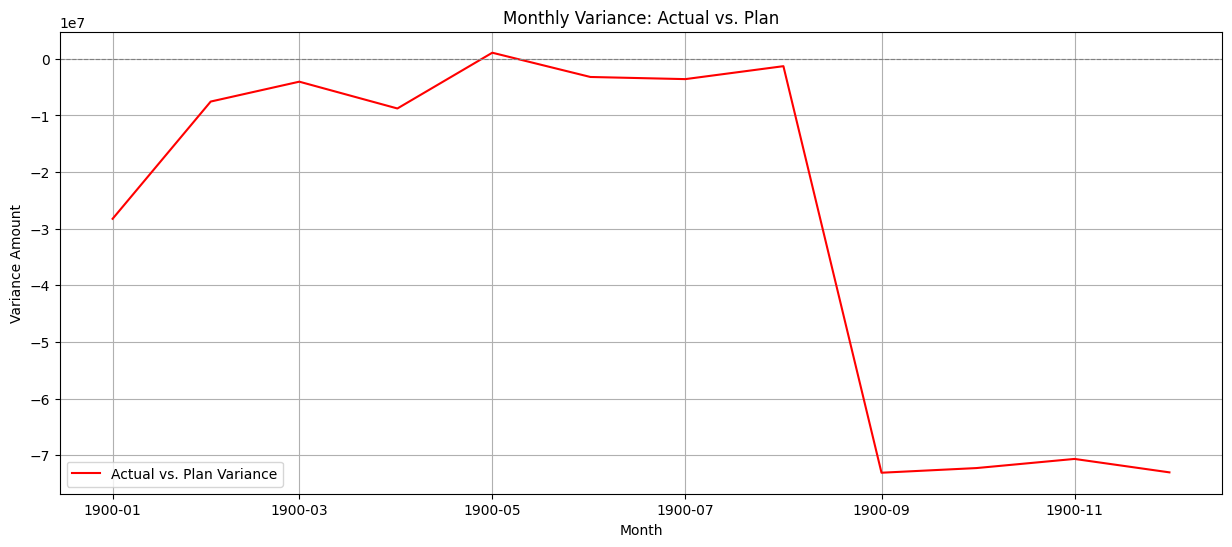

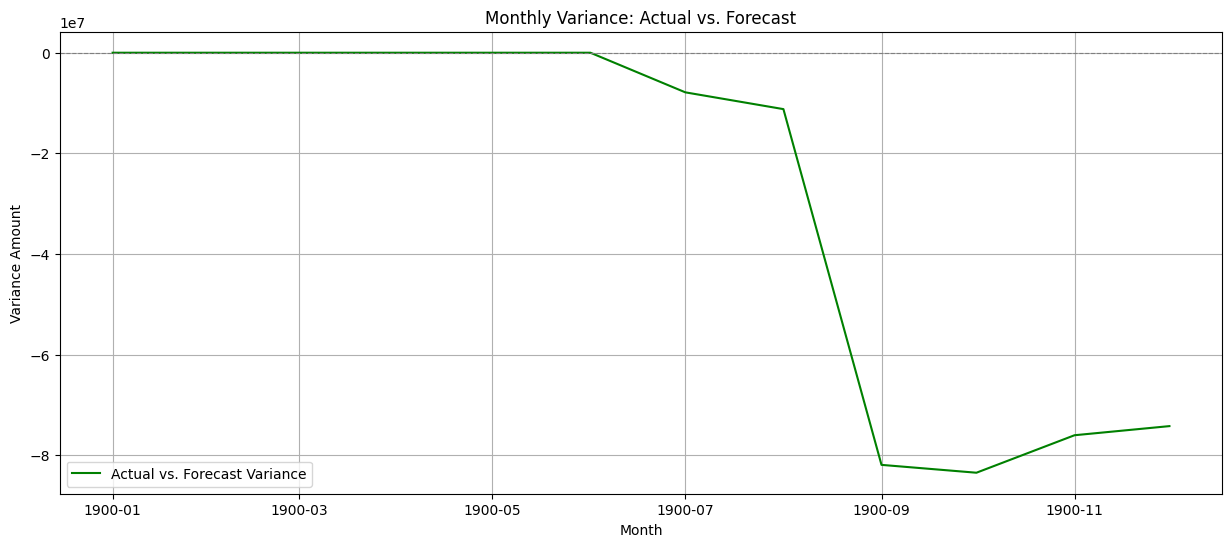

In [16]:
import matplotlib.pyplot as plt

# Convert 'Month' to datetime objects for plotting
monthly_expenditure['Month'] = monthly_expenditure['Month'].dt.to_timestamp()

plt.figure(figsize=(15, 6))
plt.plot(monthly_expenditure['Month'], monthly_expenditure['Actual'], label='Actual')
plt.plot(monthly_expenditure['Month'], monthly_expenditure['Plan'], label='Plan', linestyle='--')
plt.plot(monthly_expenditure['Month'], monthly_expenditure['Forecast'], label='Forecast', linestyle=':')
plt.title('Monthly IT Expenditure: Actual, Plan, and Forecast')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(monthly_expenditure['Month'], monthly_expenditure['Variance_Actual_Plan'], label='Actual vs. Plan Variance', color='red')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.title('Monthly Variance: Actual vs. Plan')
plt.xlabel('Month')
plt.ylabel('Variance Amount')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(monthly_expenditure['Month'], monthly_expenditure['Variance_Actual_Forecast'], label='Actual vs. Forecast Variance', color='green')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.title('Monthly Variance: Actual vs. Forecast')
plt.xlabel('Month')
plt.ylabel('Variance Amount')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Group by Business Area and calculate sums and variances
business_area_expenditure = df.groupby('Business Area').agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum',
    'Variance_Actual_Plan': 'sum',
    'Variance_Actual_Forecast': 'sum'
}).reset_index()

display(business_area_expenditure)

,Business Area,Actual,Plan,Forecast,Variance_Actual_Plan,Variance_Actual_Forecast
0,BU,7.758322e+07,1.389179e+08,1.353855e+08,-61334660.53,-5.780229e+07
1,Distribution,3.288215e+07,5.177806e+07,5.229326e+07,-18895915.53,-1.941111e+07
2,Infrastructure,1.578148e+08,2.497641e+08,2.421848e+08,-91949308.82,-8.436992e+07
3,Manufacturing,8.762577e+07,1.329863e+08,1.346530e+08,-45360513.26,-4.702726e+07
4,Office & Administrative,1.112255e+08,1.728118e+08,1.724768e+08,-61586252.61,-6.125128e+07
5,R&D,6.616350e+07,1.145604e+08,1.157973e+08,-48396916.25,-4.963380e+07
6,Services,2.243617e+07,3.958379e+07,3.775176e+07,-17147619.22,-1.531559e+07


In [14]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%b')

# Fill NaN values in 'Actual', 'Forecast', and 'Plan' with 0
df[['Actual', 'Forecast', 'Plan']] = df[['Actual', 'Forecast', 'Plan']].fillna(0)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81610 entries, 0 to 81609
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    81610 non-null  datetime64[ns]
 1   Business Area           81610 non-null  object        
 2   Region                  81610 non-null  object        
 3   Country                 81610 non-null  object        
 4   IT Sub Area             81610 non-null  object        
 5   IT Area                 81610 non-null  object        
 6   Cost element name       81610 non-null  object        
 7   Cost Element Group      81610 non-null  object        
 8   Cost Element Sub Group  81610 non-null  object        
 9   Actual                  81610 non-null  float64       
 10  Forecast                81610 non-null  float64       
 11  Plan                    81610 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(8)
me

In [15]:
# Calculate variances
df['Variance_Actual_Plan'] = df['Actual'] - df['Plan']
df['Variance_Actual_Forecast'] = df['Actual'] - df['Forecast']

# Group by month and calculate the sum of Actual, Plan, Forecast, and variances
monthly_expenditure = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Actual': 'sum',
    'Plan': 'sum',
    'Forecast': 'sum',
    'Variance_Actual_Plan': 'sum',
    'Variance_Actual_Forecast': 'sum'
}).reset_index()

# Rename the 'Date' column to 'Month' for clarity
monthly_expenditure = monthly_expenditure.rename(columns={'Date': 'Month'})

display(monthly_expenditure)

,Month,Actual,Plan,Forecast,Variance_Actual_Plan,Variance_Actual_Forecast
0,1900-01,58459736.77,86708487.65,5.845974e+07,-28248750.88,0.000000e+00
1,1900-02,65354616.00,72896037.74,6.535462e+07,-7541421.74,0.000000e+00
2,1900-03,73793454.79,77824807.84,7.379345e+07,-4031353.05,0.000000e+00
3,1900-04,66731363.58,75495932.39,6.673136e+07,-8764568.81,0.000000e+00
4,1900-05,72852082.32,71768203.39,7.285208e+07,1083878.93,0.000000e+00
5,1900-06,75502547.14,78703595.15,7.550255e+07,-3201048.01,0.000000e+00
6,1900-07,73206940.65,76785542.55,8.108350e+07,-3578601.90,-7.876555e+06
7,1900-08,69830420.44,71123330.99,8.104238e+07,-1292910.55,-1.121196e+07
8,1900-09,0.00,73104219.44,8.193991e+07,-73104219.44,-8.193991e+07
9,1900-10,0.00,72282594.69,8.350026e+07,-72282594.69,-8.350026e+07


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81610 entries, 0 to 81609
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      81610 non-null  datetime64[ns]
 1   Business Area             81610 non-null  object        
 2   Region                    81610 non-null  object        
 3   Country                   81610 non-null  object        
 4   IT Sub Area               81610 non-null  object        
 5   IT Area                   81610 non-null  object        
 6   Cost element name         81610 non-null  object        
 7   Cost Element Group        81610 non-null  object        
 8   Cost Element Sub Group    81610 non-null  object        
 9   Actual                    81610 non-null  float64       
 10  Forecast                  81610 non-null  float64       
 11  Plan                      81610 non-null  float64       
 12  Variance_Actual_Pl

/tmp/ipykernel_9602/352139147.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Business Area', y='Variance_Actual_Plan', data=business_area_expenditure, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_9602/352139147.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Variance_Actual_Plan', data=top_countries, ax=axes[1, 1], palette='plasma')
/tmp/ipykernel_9602/352139147.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IT Area', y='Variance_Actual_Plan', data=it_area_expenditure, ax=axes[2, 0], palette='cividi

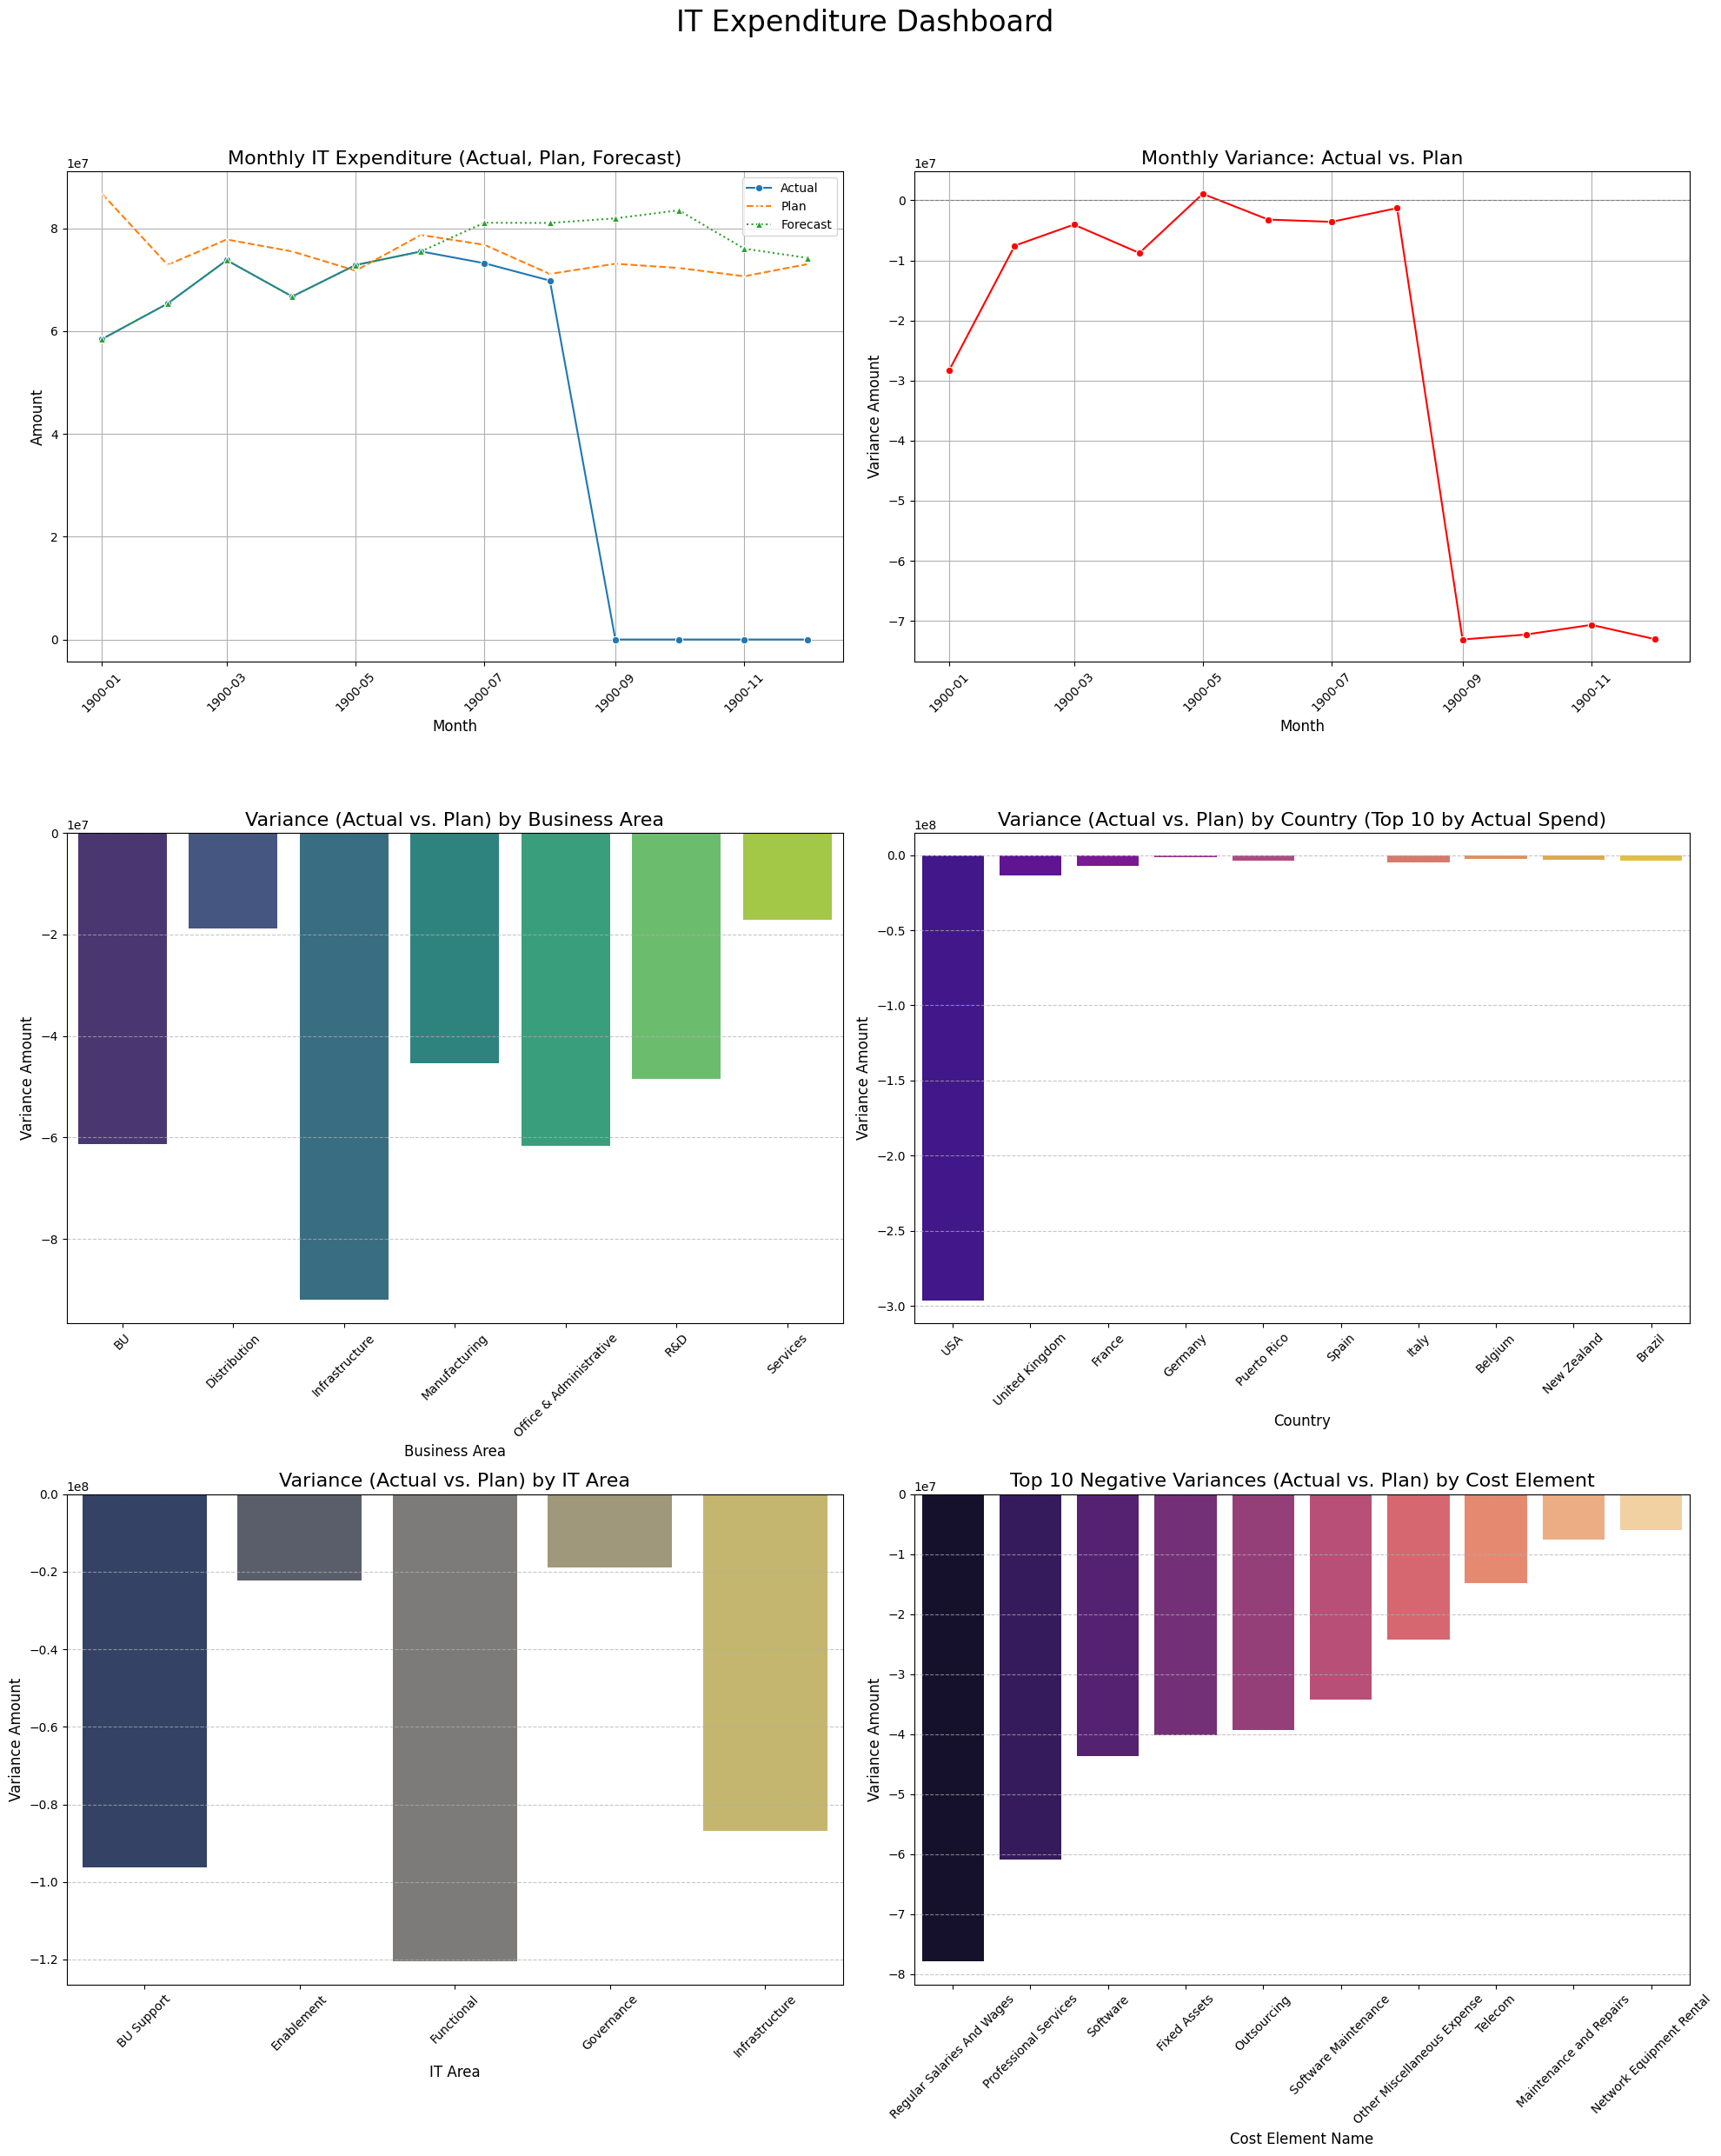

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Month' is in datetime format for plotting
monthly_expenditure['Month'] = monthly_expenditure['Month'].apply(lambda x: x.to_timestamp() if isinstance(x, pd.Period) else x)

# Create a figure with subplots for the dashboard
fig, axes = plt.subplots(3, 2, figsize=(20, 25))
fig.suptitle('IT Expenditure Dashboard', fontsize=24, y=1.02)

# Plot 1: Monthly Actual, Plan, and Forecast
sns.lineplot(x='Month', y='Actual', data=monthly_expenditure, label='Actual', ax=axes[0, 0], marker='o')
sns.lineplot(x='Month', y='Plan', data=monthly_expenditure, label='Plan', ax=axes[0, 0], linestyle='--', marker='x')
sns.lineplot(x='Month', y='Forecast', data=monthly_expenditure, label='Forecast', ax=axes[0, 0], linestyle=':', marker='^')
axes[0, 0].set_title('Monthly IT Expenditure (Actual, Plan, Forecast)', fontsize=16)
axes[0, 0].set_xlabel('Month', fontsize=12)
axes[0, 0].set_ylabel('Amount', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Monthly Variance: Actual vs. Plan
sns.lineplot(x='Month', y='Variance_Actual_Plan', data=monthly_expenditure, ax=axes[0, 1], color='red', marker='o')
axes[0, 1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('Monthly Variance: Actual vs. Plan', fontsize=16)
axes[0, 1].set_xlabel('Month', fontsize=12)
axes[0, 1].set_ylabel('Variance Amount', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True)

# Plot 3: Variance by Business Area
sns.barplot(x='Business Area', y='Variance_Actual_Plan', data=business_area_expenditure, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Variance (Actual vs. Plan) by Business Area', fontsize=16)
axes[1, 0].set_xlabel('Business Area', fontsize=12)
axes[1, 0].set_ylabel('Variance Amount', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 4: Variance by Country (Top 10)
top_countries = country_expenditure.nlargest(10, 'Actual') # Or nsmallest for largest negative variance
sns.barplot(x='Country', y='Variance_Actual_Plan', data=top_countries, ax=axes[1, 1], palette='plasma')
axes[1, 1].set_title('Variance (Actual vs. Plan) by Country (Top 10 by Actual Spend)', fontsize=16)
axes[1, 1].set_xlabel('Country', fontsize=12)
axes[1, 1].set_ylabel('Variance Amount', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 5: Variance by IT Area
sns.barplot(x='IT Area', y='Variance_Actual_Plan', data=it_area_expenditure, ax=axes[2, 0], palette='cividis')
axes[2, 0].set_title('Variance (Actual vs. Plan) by IT Area', fontsize=16)
axes[2, 0].set_xlabel('IT Area', fontsize=12)
axes[2, 0].set_ylabel('Variance Amount', fontsize=12)
axes[2, 0].tick_params(axis='x', rotation=45)
axes[2, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 6: Variance by Cost Element (Top 10 negative variances)
top_negative_cost_elements = cost_element_expenditure.nsmallest(10, 'Variance_Actual_Plan')
sns.barplot(x='Cost element name', y='Variance_Actual_Plan', data=top_negative_cost_elements, ax=axes[2, 1], palette='magma')
axes[2, 1].set_title('Top 10 Negative Variances (Actual vs. Plan) by Cost Element', fontsize=16)
axes[2, 1].set_xlabel('Cost Element Name', fontsize=12)
axes[2, 1].set_ylabel('Variance Amount', fontsize=12)
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent titles from overlapping
plt.show()

/tmp/ipykernel_9602/352139147.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Business Area', y='Variance_Actual_Plan', data=business_area_expenditure, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_9602/352139147.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Variance_Actual_Plan', data=top_countries, ax=axes[1, 1], palette='plasma')
/tmp/ipykernel_9602/352139147.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IT Area', y='Variance_Actual_Plan', data=it_area_expenditure, ax=axes[2, 0], palette='cividi

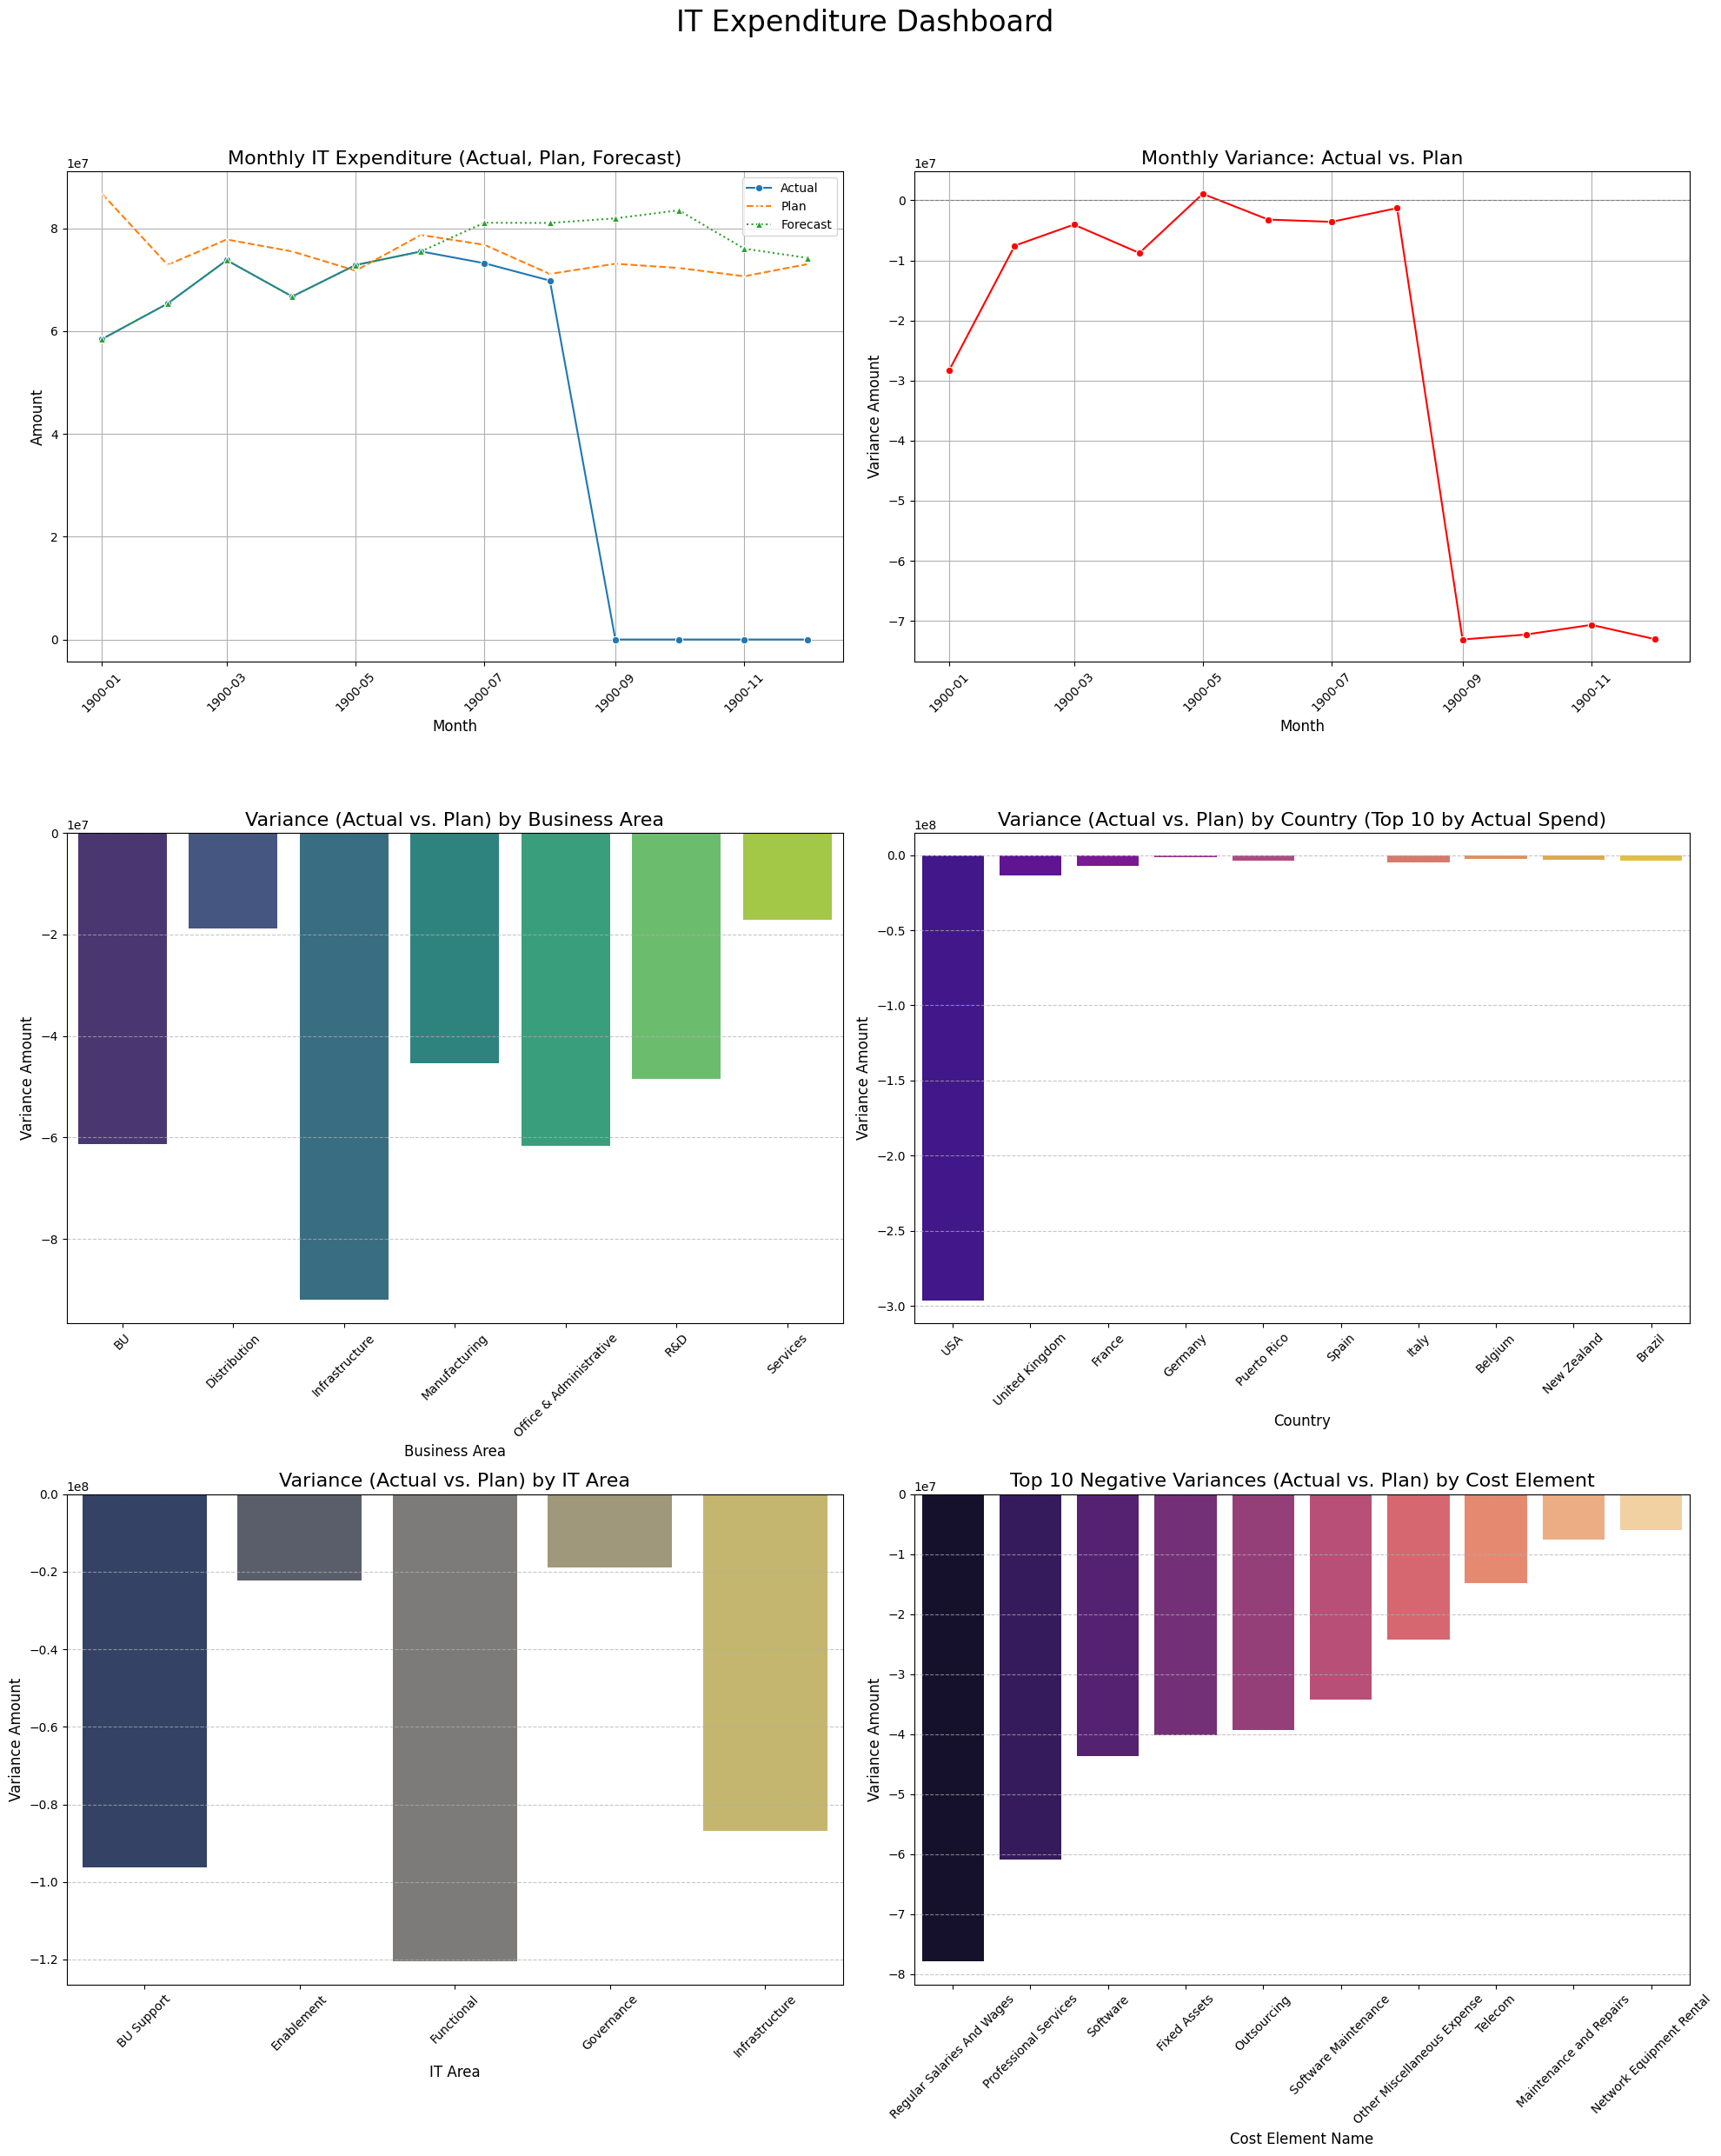

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Month' is in datetime format for plotting
monthly_expenditure['Month'] = monthly_expenditure['Month'].apply(lambda x: x.to_timestamp() if isinstance(x, pd.Period) else x)

# Create a figure with subplots for the dashboard
fig, axes = plt.subplots(3, 2, figsize=(20, 25))
fig.suptitle('IT Expenditure Dashboard', fontsize=24, y=1.02)

# Plot 1: Monthly Actual, Plan, and Forecast
sns.lineplot(x='Month', y='Actual', data=monthly_expenditure, label='Actual', ax=axes[0, 0], marker='o')
sns.lineplot(x='Month', y='Plan', data=monthly_expenditure, label='Plan', ax=axes[0, 0], linestyle='--', marker='x')
sns.lineplot(x='Month', y='Forecast', data=monthly_expenditure, label='Forecast', ax=axes[0, 0], linestyle=':', marker='^')
axes[0, 0].set_title('Monthly IT Expenditure (Actual, Plan, Forecast)', fontsize=16)
axes[0, 0].set_xlabel('Month', fontsize=12)
axes[0, 0].set_ylabel('Amount', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Monthly Variance: Actual vs. Plan
sns.lineplot(x='Month', y='Variance_Actual_Plan', data=monthly_expenditure, ax=axes[0, 1], color='red', marker='o')
axes[0, 1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('Monthly Variance: Actual vs. Plan', fontsize=16)
axes[0, 1].set_xlabel('Month', fontsize=12)
axes[0, 1].set_ylabel('Variance Amount', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True)

# Plot 3: Variance by Business Area
sns.barplot(x='Business Area', y='Variance_Actual_Plan', data=business_area_expenditure, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Variance (Actual vs. Plan) by Business Area', fontsize=16)
axes[1, 0].set_xlabel('Business Area', fontsize=12)
axes[1, 0].set_ylabel('Variance Amount', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 4: Variance by Country (Top 10)
top_countries = country_expenditure.nlargest(10, 'Actual') # Or nsmallest for largest negative variance
sns.barplot(x='Country', y='Variance_Actual_Plan', data=top_countries, ax=axes[1, 1], palette='plasma')
axes[1, 1].set_title('Variance (Actual vs. Plan) by Country (Top 10 by Actual Spend)', fontsize=16)
axes[1, 1].set_xlabel('Country', fontsize=12)
axes[1, 1].set_ylabel('Variance Amount', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 5: Variance by IT Area
sns.barplot(x='IT Area', y='Variance_Actual_Plan', data=it_area_expenditure, ax=axes[2, 0], palette='cividis')
axes[2, 0].set_title('Variance (Actual vs. Plan) by IT Area', fontsize=16)
axes[2, 0].set_xlabel('IT Area', fontsize=12)
axes[2, 0].set_ylabel('Variance Amount', fontsize=12)
axes[2, 0].tick_params(axis='x', rotation=45)
axes[2, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 6: Variance by Cost Element (Top 10 negative variances)
top_negative_cost_elements = cost_element_expenditure.nsmallest(10, 'Variance_Actual_Plan')
sns.barplot(x='Cost element name', y='Variance_Actual_Plan', data=top_negative_cost_elements, ax=axes[2, 1], palette='magma')
axes[2, 1].set_title('Top 10 Negative Variances (Actual vs. Plan) by Cost Element', fontsize=16)
axes[2, 1].set_xlabel('Cost Element Name', fontsize=12)
axes[2, 1].set_ylabel('Variance Amount', fontsize=12)
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent titles from overlapping
plt.show()

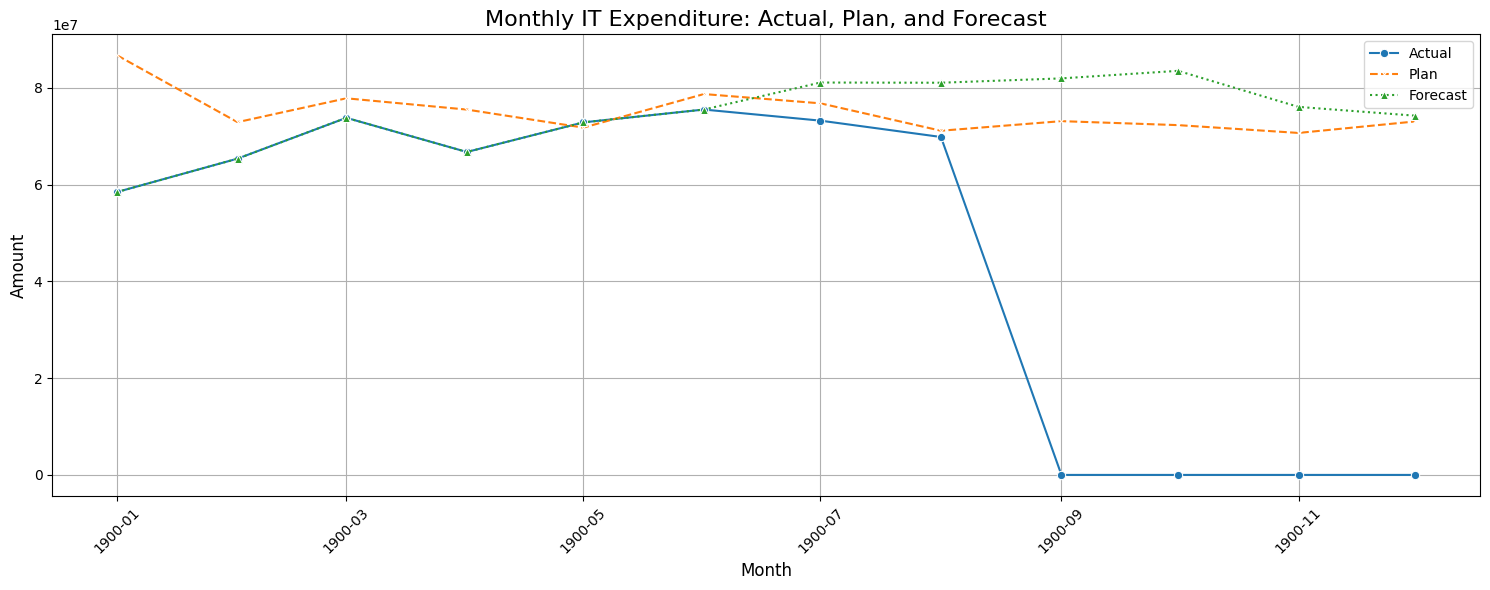

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure 'Month' is in datetime format for plotting
monthly_expenditure['Month'] = monthly_expenditure['Month'].apply(lambda x: x.to_timestamp() if isinstance(x, pd.Period) else x)

plt.figure(figsize=(15, 6))
sns.lineplot(x='Month', y='Actual', data=monthly_expenditure, label='Actual', marker='o')
sns.lineplot(x='Month', y='Plan', data=monthly_expenditure, label='Plan', linestyle='--', marker='x')
sns.lineplot(x='Month', y='Forecast', data=monthly_expenditure, label='Forecast', linestyle=':', marker='^')
plt.title('Monthly IT Expenditure: Actual, Plan, and Forecast', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

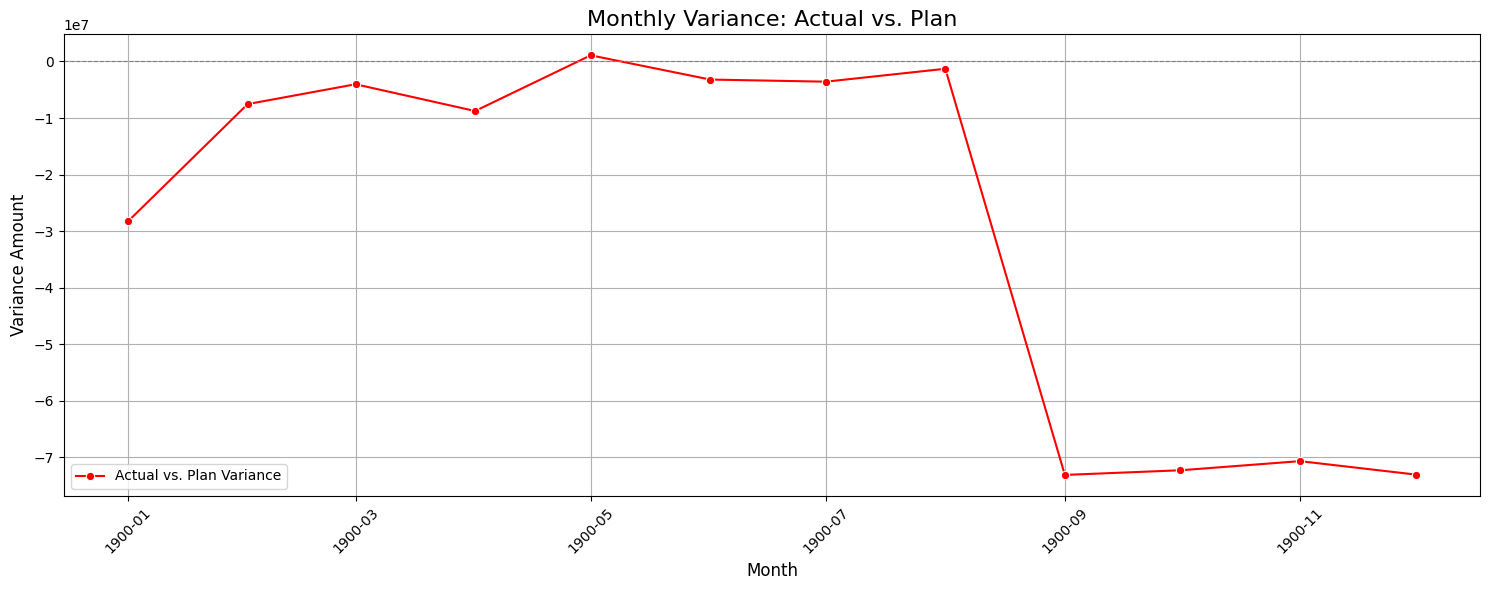

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure 'Month' is in datetime format for plotting
monthly_expenditure['Month'] = monthly_expenditure['Month'].apply(lambda x: x.to_timestamp() if isinstance(x, pd.Period) else x)

plt.figure(figsize=(15, 6))
sns.lineplot(x='Month', y='Variance_Actual_Plan', data=monthly_expenditure, label='Actual vs. Plan Variance', color='red', marker='o')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.title('Monthly Variance: Actual vs. Plan', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Variance Amount', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  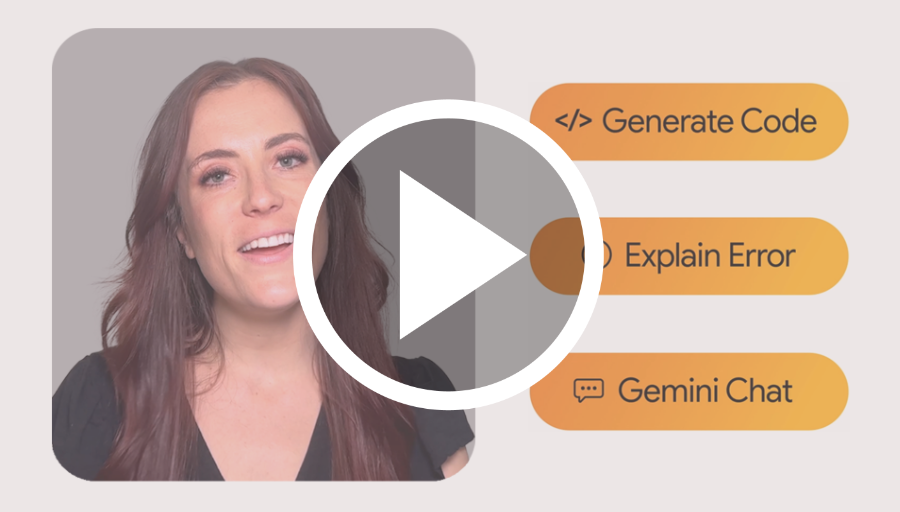
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

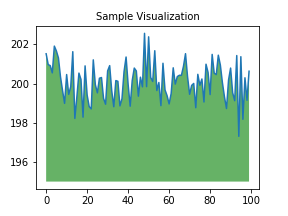

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
